# DSA 210 Project

## Topic
**Modeling the Impact of Bamboo Availability on Giant Panda Population**

## Main hypothesis
- **H0:** Bamboo availability has no significant relationship with panda population.
- **H1:** Bamboo availability has a significant relationship with panda population.

## Data sources used in this part
- **Panda population:** WWF / IUCN census-based estimates (interpolated across years)
- **Climate:** NOAA yearly climate summaries for Chengdu, Xi'an, and Lanzhou
- **Bamboo availability proxy:** occurrence-based bamboo observations filtered to relevant panda-food genera (*Fargesia*, *Bashania*)

## Scope note
This is not the final version of the project. At this stage, the analysis is based only on the currently available datasets: bamboo occurrence records, climate variables, and panda population. Additional datasets will be added later to construct a more complete and theoretically stronger Bamboo Availability Index. Therefore, the current analysis should be interpreted as a preliminary step rather than the final model.

## 1. Setup
This section imports the required libraries and prepares the notebook to work in either **Google Colab** or a standard **Jupyter** environment.


In [26]:
# 1. DEPENDENCIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, shapiro
from scipy import stats as sp_stats
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

try:
    from google.colab import files
    IN_COLAB = True
except Exception:
    IN_COLAB = False
    files = None

print(f"Running in Colab: {IN_COLAB}")


Running in Colab: True


## 2. Data collection and cleaning

This section loads the bamboo dataset, keeps the relevant columns, filters the study period to **1974–2002**, and limits records to bamboo genera relevant to giant panda feeding ecology.


In [27]:
# 2. LOAD & CLEAN BAMBOO DATA
DEFAULT_BAMBOO_FILE = None

def load_bamboo_csv(default_path=None):
    """Load bamboo data from a local path or Colab upload."""
    if default_path and Path(default_path).exists():
        return pd.read_csv(default_path, sep=None, engine='python')

    if IN_COLAB:
        uploaded = files.upload()
        if not uploaded:
            raise FileNotFoundError("No file was uploaded.")
        bamboo_file = next(iter(uploaded))
        return pd.read_csv(bamboo_file, sep=None, engine='python')

    raise FileNotFoundError(
        "No bamboo CSV found. Set DEFAULT_BAMBOO_FILE to your local CSV path, "
        "or run this notebook in Google Colab and upload the file when prompted."
    )

bamboo_raw = load_bamboo_csv(DEFAULT_BAMBOO_FILE)

WANTED_COLS = [
    'year', 'species', 'scientificName', 'verbatimScientificName',
    'decimalLatitude', 'decimalLongitude', 'stateProvince',
    'occurrenceStatus', 'individualCount'
]

bamboo_df = bamboo_raw[[c for c in WANTED_COLS if c in bamboo_raw.columns]].copy()

bamboo_df['year'] = pd.to_numeric(bamboo_df['year'], errors='coerce')
bamboo_df = bamboo_df.query('1974 <= year <= 2002').copy()

name_cols = [c for c in ('species', 'scientificName', 'verbatimScientificName') if c in bamboo_df.columns]
if not name_cols:
    raise ValueError("The bamboo dataset must contain at least one scientific-name column.")

bamboo_df['_name'] = bamboo_df[name_cols].astype(str).agg(' '.join, axis=1)
bamboo_df = bamboo_df[bamboo_df['_name'].str.contains('Fargesia|Bashania', case=False, na=False)]

if 'occurrenceStatus' in bamboo_df.columns:
    bamboo_df = bamboo_df[bamboo_df['occurrenceStatus'].astype(str).str.upper() == 'PRESENT']

bamboo_df = bamboo_df.dropna(subset=['year']).copy()
bamboo_df['year'] = bamboo_df['year'].astype(int)

print('Bamboo rows after cleaning:', len(bamboo_df))
display(bamboo_df.head())


Saving 0005525-260409193756587 2.csv to 0005525-260409193756587 2 (2).csv
Bamboo rows after cleaning: 431


,year,species,scientificName,verbatimScientificName,decimalLatitude,decimalLongitude,stateProvince,occurrenceStatus,individualCount,_name
0,1981,Fargesia nitida,Fargesia nitida (Mitford) Keng f. ex T.P.Yi,Fargesia nitida,25.841921,98.857727,云南,PRESENT,NaN,Fargesia nitida Fargesia nitida (Mitford) Keng...
1,1981,Fargesia nitida,Fargesia nitida (Mitford) Keng f. ex T.P.Yi,Fargesia nitida,25.841921,98.857727,云南,PRESENT,NaN,Fargesia nitida Fargesia nitida (Mitford) Keng...
2,1981,Fargesia nitida,Fargesia nitida (Mitford) Keng f. ex T.P.Yi,Fargesia nitida,25.841921,98.857727,云南,PRESENT,NaN,Fargesia nitida Fargesia nitida (Mitford) Keng...
3,1981,Fargesia nitida,Fargesia nitida (Mitford) Keng f. ex T.P.Yi,Fargesia nitida,26.876096,100.229945,云南,PRESENT,NaN,Fargesia nitida Fargesia nitida (Mitford) Keng...
5,1981,Fargesia nitida,Fargesia nitida (Mitford) Keng f. ex T.P.Yi,Fargesia nitida,27.177166,99.287170,云南,PRESENT,NaN,Fargesia nitida Fargesia nitida (Mitford) Keng...


## 3. Bamboo Availability Index
A preliminary **Bamboo Availability Index (BAI)** is created by counting yearly bamboo occurrence records and applying min-max normalization.

This gives a simple milestone-ready proxy for bamboo availability before richer ecological enrichment is added in later stages.


In [28]:
# 3. BAMBOO AVAILABILITY INDEX
# Proxy: normalised yearly count of bamboo occurrence records (min-max scaling)
bamboo_yearly = bamboo_df.groupby('year').size().reset_index(name='bamboo_count')

lo, hi = bamboo_yearly['bamboo_count'].min(), bamboo_yearly['bamboo_count'].max()
bamboo_yearly['bamboo_index'] = (
    (bamboo_yearly['bamboo_count'] - lo) / (hi - lo) if hi > lo else 1.0
)
bamboo_yearly = bamboo_yearly.round(3)


## 4. Climate data
The yearly climate data below aggregates precipitation and temperature from three stations:
- Chengdu
- Xi'an
- Lanzhou

These values are used both for EDA and for testing whether climate is associated with the bamboo proxy.


In [29]:
# 4. CLIMATE DATA (from NOAA PDFs, corrected)
# Source: NOAA NCEI Global Summary of the Year
# Stations: Chengdu (CHM00056294), Xi'an (CHM00057036), Lanzhou (CHM00052889)
# All temperatures in °F, precipitation in inches.

years = list(range(1974, 2003))

stations = {
    'Chengdu': {
        'precipitation': [
            39.48, 31.78, 34.95, 34.85, 36.08, 28.43, 34.91, 38.26, 32.26, 29.61,
            39.28, 35.90, 35.51, 28.38, 42.31, 38.08, 44.28, 23.38, 34.23, 28.21,
            37.23, 35.61, 27.99, 30.83, 35.65, 30.96, 30.84, 32.53, 30.02
        ],
        'temperature': [
            61.2, 62.1, 60.7, 62.0, 62.4, 62.3, 61.9, 61.6, 61.3, 61.7,
            60.9, 61.3, 61.3, 62.8, 61.2, 61.2, 62.7, 62.2, 61.4, 61.9,
            62.9, 62.4, 61.5, 63.0, 64.3, 63.3, 62.8, 64.1, 64.3
        ]
    },
    'Xian': {
        'precipitation': [
            24.67, 26.44, 20.23, 13.63, 20.87, 19.33, 20.16, 28.59, 19.63, 35.56,
            26.18, 19.34, 15.86, 23.96, 25.92, 24.67, 18.05, 24.13, 21.24, 17.35,
            20.91, 12.29, 28.09, 14.25, 23.64, 23.21, 21.22, 15.98, 16.00
        ],
        'temperature': [
            56.5, 57.0, 56.1, 58.0, 57.9, 57.7, 56.8, 57.3, 57.5, 56.6,
            56.0, 56.6, 57.5, 57.7, 57.0, 57.1, 57.8, 57.7, 57.1, 56.7,
            58.9, 59.4, 57.6, 59.6, 60.4, 60.2, 59.0, 59.9, 60.9
        ]
    },
    'Lanzhou': {
        'precipitation': [
            10.28, 10.98, 14.25, 12.53, 21.52, 15.89,  7.45,  7.90,  9.19, 12.09,
            13.78, 14.97, 12.34, 10.89, 12.58, 10.98, 12.44, 11.09, 11.99, 11.80,
            12.53, 14.50, 14.52,  9.27, 12.57, 12.94, 14.17, 10.64, 11.03
        ],
        'temperature': [
            49.8, 50.0, 48.6, 49.5, 50.5, 50.3, 50.8, 50.7, 51.1, 50.0,
            49.3, 50.1, 50.5, 52.1, 51.1, 51.3, 52.1, 52.1, 50.6, 50.9,
            52.5, 51.4, 50.8, 53.1, 54.1, 53.5, 53.2, 53.1, 53.5
        ]
    }
}

# Build combined DataFrame and compute yearly mean in one pass
climate_df = pd.concat(
    [pd.DataFrame({'year': years, **v, 'station': k}) for k, v in stations.items()],
    ignore_index=True
)

climate_yearly = (
    climate_df.groupby('year')[['precipitation', 'temperature']]
    .mean()
    .round(3)
    .reset_index()
)


## 5. Panda population series
Because census counts are only available for anchor years, yearly values are linearly interpolated to create a continuous annual series for the milestone analysis.


In [30]:
# 5. PANDA POPULATION (linear interpolation between census years)
# Known census estimates: 1975 ≈ 2459, 1986 ≈ 1114, 2003 ≈ 1596
panda_anchors = pd.DataFrame({'year': [1975, 1986, 2003], 'panda_population': [2459, 1114, 1596]})

panda_df = (
    pd.DataFrame({'year': range(1974, 2004)})
    .merge(panda_anchors, on='year', how='left')
)
# interpolate(limit_direction='both') handles interior gaps AND boundary fill — bfill() is redundant
panda_df['panda_population'] = (
    panda_df['panda_population']
    .interpolate(method='linear', limit_direction='both')
    .round()
    .astype(int)
)
panda_df = panda_df.query('1974 <= year <= 2002').copy()


## 6. Merge all components into one analytical dataset
This creates the dataset used in the rest of the notebook.


In [31]:
# 6. MERGE
final_df = (
    climate_yearly
    .merge(bamboo_yearly, on='year', how='inner')
    .merge(panda_df,      on='year', how='inner')
    .round(3)
)


In [32]:
print('Merged dataset shape:', final_df.shape)
display(final_df.head())


Merged dataset shape: (26, 6)


,year,precipitation,temperature,bamboo_count,bamboo_index,panda_population
0,1974,24.810,55.833,12,0.145,2459
1,1975,23.067,56.367,22,0.276,2459
2,1976,23.143,55.133,77,1.000,2337
3,1977,20.337,56.500,21,0.263,2214
4,1978,26.157,56.933,36,0.461,2092


## 7. Exploratory Data Analysis (EDA)
This section addresses the **EDA** part of the project by visualizing:
- regional precipitation over time
- regional temperature over time
- bamboo availability over time
- panda population over time
- climate vs bamboo relationships
- bamboo vs panda relationship


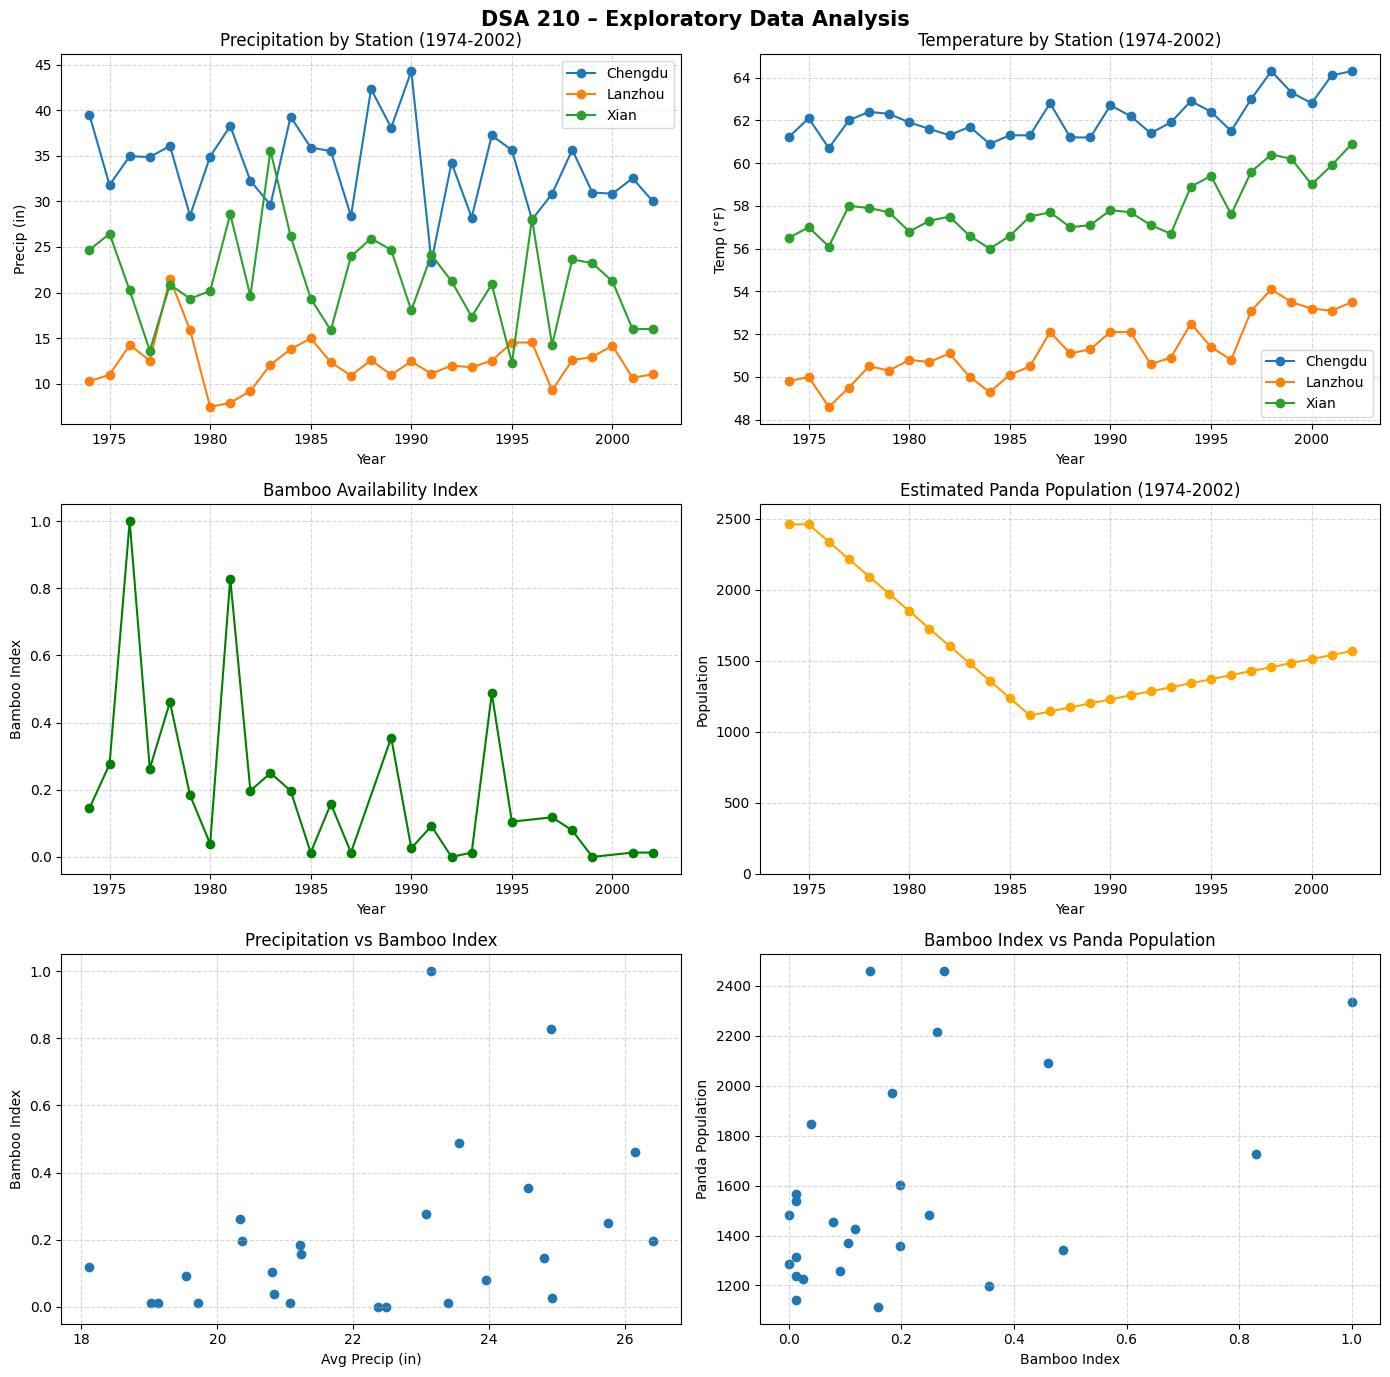

In [33]:
# 7. EDA – ALL PLOTS IN ONE FIGURE GRID
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
fig.suptitle('DSA 210 – Exploratory Data Analysis', fontsize=15, fontweight='bold')

# Regional precipitation
for name, grp in climate_df.groupby('station'):
    axes[0, 0].plot(grp['year'], grp['precipitation'], marker='o', label=name)
axes[0, 0].set(title='Precipitation by Station (1974-2002)', xlabel='Year', ylabel='Precip (in)')
axes[0, 0].legend(); axes[0, 0].grid(True, linestyle='--', alpha=0.5)

# Regional temperature
for name, grp in climate_df.groupby('station'):
    axes[0, 1].plot(grp['year'], grp['temperature'], marker='o', label=name)
axes[0, 1].set(title='Temperature by Station (1974-2002)', xlabel='Year', ylabel='Temp (°F)')
axes[0, 1].legend(); axes[0, 1].grid(True, linestyle='--', alpha=0.5)

# Bamboo index
axes[1, 0].plot(bamboo_yearly['year'], bamboo_yearly['bamboo_index'], marker='o', color='green')
axes[1, 0].set(title='Bamboo Availability Index', xlabel='Year', ylabel='Bamboo Index')
axes[1, 0].grid(True, linestyle='--', alpha=0.5)

# Panda population
axes[1, 1].plot(panda_df['year'], panda_df['panda_population'], marker='o', color='orange')
axes[1, 1].set(title='Estimated Panda Population (1974-2002)', xlabel='Year', ylabel='Population')
axes[1, 1].set_ylim(0, 2600); axes[1, 1].grid(True, linestyle='--', alpha=0.5)

# Precipitation vs Bamboo
axes[2, 0].scatter(final_df['precipitation'], final_df['bamboo_index'])
axes[2, 0].set(title='Precipitation vs Bamboo Index', xlabel='Avg Precip (in)', ylabel='Bamboo Index')
axes[2, 0].grid(True, linestyle='--', alpha=0.5)

# Bamboo vs Panda
axes[2, 1].scatter(final_df['bamboo_index'], final_df['panda_population'])
axes[2, 1].set(title='Bamboo Index vs Panda Population', xlabel='Bamboo Index', ylabel='Panda Population')
axes[2, 1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


## 8. Hypothesis testing
We test three relationships:
1. **Precipitation → Bamboo Index**
2. **Temperature → Bamboo Index**
3. **Bamboo Index → Panda Population**

For each relationship, the notebook runs:
- **Shapiro-Wilk** normality checks
- **Pearson correlation**
- **simple linear regression**
- decision at **α = 0.05**


In [34]:
#  8. HYPOTHESIS TESTS
ALPHA = 0.05

TESTS = [
    ('Precipitation → Bamboo Index', 'precipitation', 'bamboo_index',
     'Avg Precipitation (in)', 'Bamboo Availability Index'),
    ('Temperature → Bamboo Index',   'temperature',   'bamboo_index',
     'Avg Temperature (°F)',   'Bamboo Availability Index'),
    ('Bamboo Index → Panda Population', 'bamboo_index', 'panda_population',
     'Bamboo Availability Index', 'Panda Population'),
]

def run_hypothesis_test(df, x_col, y_col, label, x_label, y_label, alpha=0.05):
    common = df[[x_col, y_col]].dropna().copy()
    x, y = common[x_col], common[y_col]
    n = len(x)

    if n < 3:
        raise ValueError(f'Not enough observations for {label}.')

    _, p_norm_x = shapiro(x)
    _, p_norm_y = shapiro(y)
    x_normal = 'Normal' if p_norm_x >= alpha else 'Non-normal'
    y_normal = 'Normal' if p_norm_y >= alpha else 'Non-normal'

    r, p_val = pearsonr(x, y)
    decision = 'Reject H0 ✓ (significant)' if p_val < alpha else 'Fail to reject H0 ✗'

    slope, intercept, r_val, _, se = sp_stats.linregress(x, y)
    r2 = r_val ** 2
    x_line = np.linspace(x.min(), x.max(), 200)
    y_line = slope * x_line + intercept

    x_mean = x.mean()
    t_crit = sp_stats.t.ppf(0.975, df=n - 2)
    denom = ((x - x_mean) ** 2).sum()
    if denom == 0:
        se_fit = np.zeros_like(x_line)
    else:
        se_fit = se * np.sqrt(1/n + (x_line - x_mean)**2 / denom)
    ci_upper = y_line + t_crit * se_fit
    ci_lower = y_line - t_crit * se_fit

    print(f'=== {label} ===')
    print(f'n = {n}')
    print(f'Shapiro p ({x_col}): {p_norm_x:.4f} -> {x_normal}')
    print(f'Shapiro p ({y_col}): {p_norm_y:.4f} -> {y_normal}')
    print(f'Pearson r = {r:.4f}')
    print(f'p-value   = {p_val:.4f}')
    print(f'R^2       = {r2:.4f}')
    print(f'Decision  = {decision}')
    print()

    return (label, x_label, y_label, x, y, x_line, y_line, ci_lower, ci_upper, r, p_val, r2)

results = []
for label, x_col, y_col, x_label, y_label in TESTS:
    results.append(run_hypothesis_test(final_df, x_col, y_col, label, x_label, y_label, alpha=ALPHA))


=== Precipitation → Bamboo Index ===
n = 26
Shapiro p (precipitation): 0.4032 -> Normal
Shapiro p (bamboo_index): 0.0000 -> Non-normal
Pearson r = 0.4031
p-value   = 0.0412
R^2       = 0.1625
Decision  = Reject H0 ✓ (significant)

=== Temperature → Bamboo Index ===
n = 26
Shapiro p (temperature): 0.0426 -> Non-normal
Shapiro p (bamboo_index): 0.0000 -> Non-normal
Pearson r = -0.4028
p-value   = 0.0413
R^2       = 0.1623
Decision  = Reject H0 ✓ (significant)

=== Bamboo Index → Panda Population ===
n = 26
Shapiro p (bamboo_index): 0.0000 -> Non-normal
Shapiro p (panda_population): 0.0034 -> Non-normal
Pearson r = 0.4431
p-value   = 0.0234
R^2       = 0.1964
Decision  = Reject H0 ✓ (significant)



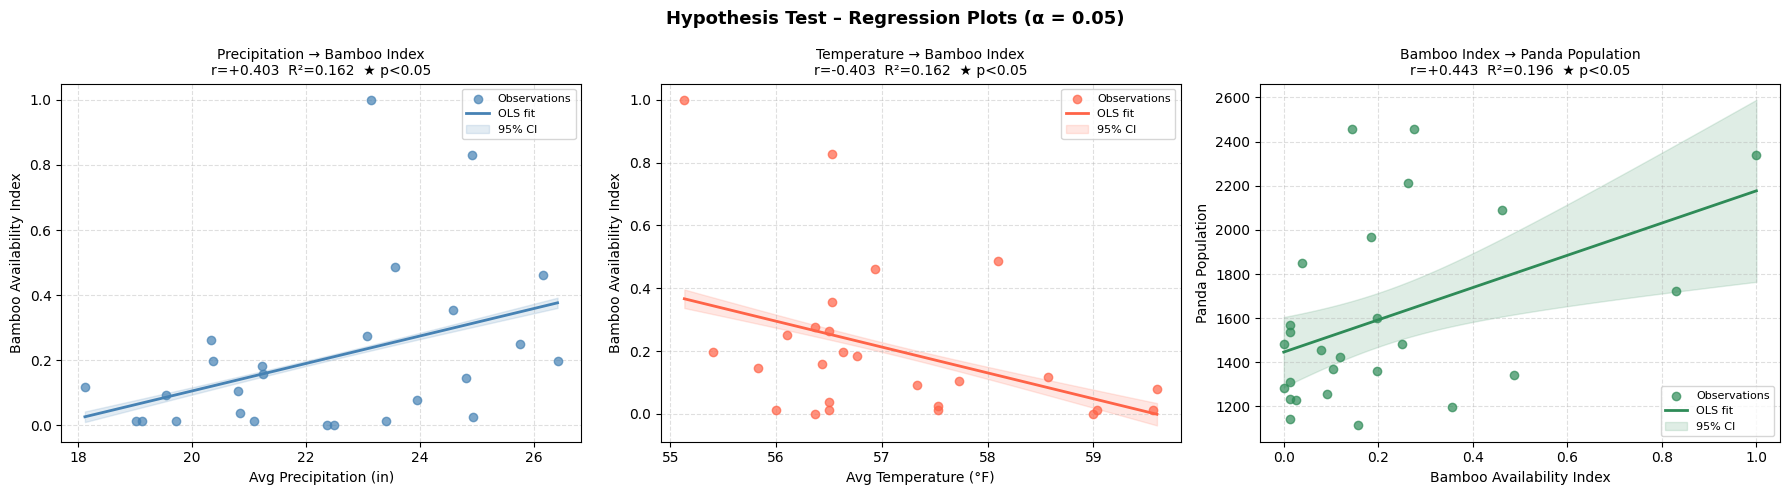

In [35]:
# 8b. REGRESSION PLOTS WITH CONFIDENCE BANDS
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Hypothesis Test – Regression Plots (α = 0.05)', fontsize=13, fontweight='bold')

colors = ['steelblue', 'tomato', 'seagreen']

for ax, (label, x_label, y_label, x, y, x_line, y_line, ci_lower, ci_upper, r, p_val, r2), color in zip(axes, results, colors):
    ax.scatter(x, y, color=color, alpha=0.7, zorder=3, label='Observations')
    ax.plot(x_line, y_line, color=color, linewidth=2, label=f'OLS fit')
    ax.fill_between(x_line, ci_lower, ci_upper, alpha=0.15, color=color, label='95% CI')
    sig_marker = '★ p<0.05' if p_val < 0.05 else 'p≥0.05'
    ax.set_title(f'{label}\nr={r:+.3f}  R²={r2:.3f}  {sig_marker}', fontsize=10)
    ax.set_xlabel(x_label); ax.set_ylabel(y_label)
    ax.legend(fontsize=8); ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


In [36]:
# 8c. SUMMARY TABLE
summary_rows = []
for label, x_label, y_label, x, y, x_line, y_line, ci_lower, ci_upper, r, p_val, r2 in results:
    summary_rows.append({
        'Relationship':  label,
        'n':             len(x),
        'Pearson r':     round(r, 4),
        'p-value':       round(p_val, 4),
        'R²':            round(r2, 4),
        'Significant?':  'Yes ✓' if p_val < 0.05 else 'No ✗',
    })

summary_tbl = pd.DataFrame(summary_rows)
print('=== HYPOTHESIS TEST SUMMARY TABLE ===')
print(summary_tbl.to_string(index=False))


=== HYPOTHESIS TEST SUMMARY TABLE ===
                   Relationship  n  Pearson r  p-value     R² Significant?
   Precipitation → Bamboo Index 26     0.4031   0.0412 0.1625        Yes ✓
     Temperature → Bamboo Index 26    -0.4028   0.0413 0.1623        Yes ✓
Bamboo Index → Panda Population 26     0.4431   0.0234 0.1964        Yes ✓


In [37]:
# 9. SUMMARY & SAVE
print('=== SUMMARY STATISTICS ===')
print(final_df[['panda_population', 'bamboo_index', 'precipitation', 'temperature']].describe().round(3))

final_df.to_csv('final_merged_dataset.csv', index=False)
bamboo_yearly.to_csv('bamboo_yearly_index.csv', index=False)
climate_df.to_csv('climate_per_station.csv', index=False)
climate_yearly.to_csv('climate_yearly_average.csv', index=False)
summary_tbl.to_csv('hypothesis_test_summary.csv', index=False)

print('\nSaved files:')
for f in [
    'final_merged_dataset.csv',
    'bamboo_yearly_index.csv',
    'climate_per_station.csv',
    'climate_yearly_average.csv',
    'hypothesis_test_summary.csv',
]:
    print('-', f)

if IN_COLAB:
    for f in [
        'final_merged_dataset.csv',
        'bamboo_yearly_index.csv',
        'climate_per_station.csv',
        'climate_yearly_average.csv',
        'hypothesis_test_summary.csv',
    ]:
        files.download(f)


=== SUMMARY STATISTICS ===
       panda_population  bamboo_index  precipitation  temperature
count            26.000        26.000         26.000       26.000
mean           1596.038         0.205         22.342       57.097
std             414.432         0.251          2.402        1.230
min            1114.000         0.000         18.117       55.133
25%            1291.000         0.016         20.470       56.384
50%            1467.500         0.132         22.428       56.583
75%            1817.250         0.260         24.421       57.683
max            2459.000         1.000         26.413       59.600

Saved files:
- final_merged_dataset.csv
- bamboo_yearly_index.csv
- climate_per_station.csv
- climate_yearly_average.csv
- hypothesis_test_summary.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Results:**

The regression analysis shows that precipitation has a moderate positive
effect on the Bamboo Availability Index (r = 0.403, R² = 0.162, p < 0.05), indicating that higher rainfall is associated with increased bamboo availability.

In contrast, temperature has a moderate negative effect on the Bamboo Availability Index (r = -0.403, R² = 0.162, p < 0.05). This suggests that higher temperatures tend to reduce bamboo availability, likely due to less favorable growing conditions.

Finally, the Bamboo Availability Index has a moderate positive relationship with panda population (r = 0.443, R² = 0.196, p < 0.05), indicating that higher bamboo availability supports larger panda populations.


**Conclusion:**

All relationships are statistically significant (p < 0.05). These results support the hypothesis that climate variables (temperature and precipitation) affect panda populations indirectly through their impact on bamboo availability, while bamboo availability has a direct positive effect on panda population.